## Ocean Modelling: Exercise 10
#### AI Declaration: code from claud was used to write the code to create the plots
Run the following script using python: advection analytical.py (note: this is not a jupyter notebook)
Change it into a notebook and show what happens when:
1. you change the values of dx and c
2. you increase or decrease the parameter σ

To learn more about animations with matplotlib: https://towardsdatascience.com/animations-with-matplotlib-d96375c5442c

#### Linear Advection in 1D: Analytical Solution

grid size : 41
number of timesteps : 44


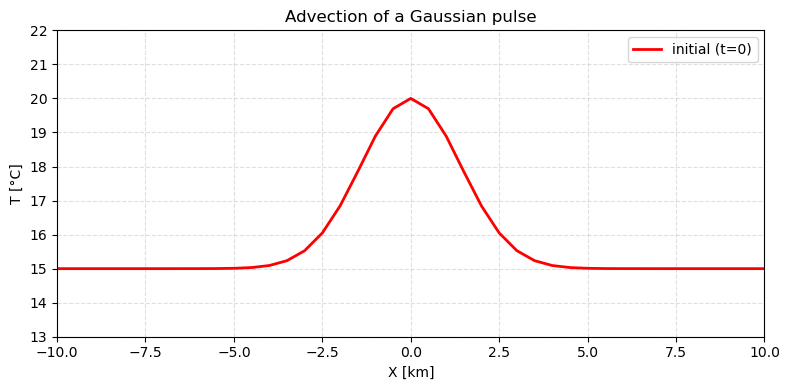

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# problem parameters
c = 1          # advection speed [m/s]
dx = 500       # x resolution [m]
dt = 200       # time step [s]
t0 = 0.        # initial time
tmax = 0.1     # duration of simulation [days]
xmax = 10.e3   # length of the basin [m]

# grid definition
NT = int(tmax * 86400 / dt) + 1
t = np.zeros(NT)
x = np.arange(-xmax, xmax + dx, dx)
IM = len(x)

print(f'grid size : {IM}')
print(f'number of timesteps : {NT}')

# array to store the analytical solution
T = np.zeros((NT, IM))

# initial conditions
T0 = 15
sigma = 2000
A = 5

def Gaussian(x, shift=0):
    return T0 + A * np.exp(-((x - shift) / sigma) ** 2)

# precompute all frames
for n in range(NT):
    t[n] = t0 + n * dt
    T[n, :] = Gaussian(x, shift=c * t[n])

# set up figure
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlabel('X [km]')
ax.set_ylabel('T [°C]')
ax.set_xlim(-xmax / 1000, xmax / 1000)
ax.set_ylim(13, 22)
ax.set_title('Advection of a Gaussian pulse')
ax.grid(True, linestyle='--', alpha=0.4)

# static initial condition in red
ax.plot(x / 1000, T[0, :], 'r', linewidth=2, label='initial (t=0)')

# animated line (grey, updates each frame)
line, = ax.plot([], [], '-', color=[0.5, 0.5, 0.5], linewidth=1.5)
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)
ax.legend(loc='upper right')

def init():
    line.set_data([], [])
    time_text.set_text('')
    return line, time_text

def update(n):
    line.set_data(x / 1000, T[n, :])
    time_text.set_text(f'Time: {t[n]/3600:.2f} h')
    return line, time_text

ani = animation.FuncAnimation(fig, update, frames=range(1, NT), init_func=init, interval=100, blit=True, repeat=True)

plt.tight_layout()
plt.show()

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# fixed parameters 
dt   = 200
t0   = 0.
tmax = 0.1
xmax = 10e3
T0   = 15
A    = 5

def plot_advection(c, dx, sigma):
    NT = int(tmax * 86400 / dt) + 1
    t  = np.array([t0 + n * dt for n in range(NT)])
    x  = np.arange(-xmax, xmax + dx, dx)

    def Gaussian(x, shift=0):
        return T0 + A * np.exp(-((x - shift) / sigma) ** 2)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.set_xlabel('X [km]')
    ax.set_ylabel('T [°C]')
    ax.set_xlim(-xmax / 1000, xmax / 1000)
    ax.set_ylim(T0 - 1, T0 + A + 2)
    ax.set_title(f'Analytical Advection with c={c} m/s,  dx={dx} m,  σ={sigma} m')
    ax.grid(True, linestyle='--', alpha=0.4)

    # plot all time steps as fading grey lines
    for n in range(NT):
        alpha = 0.2 + 0.8 * (n / (NT - 1))
        color = [0.4, 0.6, 0.8]
        ax.plot(x / 1000, Gaussian(x, shift=c * t[n]),
                color=color, alpha=alpha, linewidth=1.2)

    # initial and final in bold
    ax.plot(x / 1000, Gaussian(x),'r',  linewidth=2, label=f't = 0 h')
    ax.plot(x / 1000, Gaussian(x, shift=c*t[-1]), 'steelblue', linewidth=2,
            label=f't = {t[-1]/3600:.2f} h')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# sliders
widgets.interact(
    plot_advection,
    c     = widgets.FloatSlider(value=1,    min=0.1, max=10,   step=0.1,  description='c [m/s]',  style={'description_width': '80px'}, layout=widgets.Layout(width='500px')),
    dx    = widgets.IntSlider  (value=500,  min=100, max=3000, step=100,  description='dx [m]',   style={'description_width': '80px'}, layout=widgets.Layout(width='500px')),
    sigma = widgets.IntSlider  (value=2000, min=200, max=6000, step=100,  description='σ [m]',    style={'description_width': '80px'}, layout=widgets.Layout(width='500px')),)


interactive(children=(FloatSlider(value=1.0, description='c [m/s]', layout=Layout(width='500px'), max=10.0, mi…

<function __main__.plot_advection(c, dx, sigma)>

#### Effects of Changing the Parameters
initial parameters:
- c = 1          # advection speed [m/s]
- dx = 500       # x resolution [m]
- sigma = 2000   # half width of Gaussian Temperature Pulse (initial temperature anomaly)

- when c increases (and dx=500 and sigma=2000 are kept constant), the analytical advection curve shifts to the right and spreads out so the temperature pulse travels further to the right and moves faster 
- when dx increases (and c=1 and sigma=2000 are kept constant), the resolution of the analytical advection curve becomes coarser and instead of showing a smooth curve, becomes sharp and angular
- when sigma increases (and c=1 and dx=200 are kept constant), the width of the analytical advection curve increases and it becomes wider and flatter